# Setup

In [ ]:
from google.colab import files                                                                                                                                                                                       
uploaded_1 = files.upload()

Saving sc_cases_cleaned.pkl to sc_cases_cleaned (1).pkl


In [ ]:
uploaded_2 = files.upload()

Saving vocab.pkl to vocab (1).pkl


In [3]:
import warnings; warnings.simplefilter('ignore')
# set this to your working directory
%matplotlib inline
import pandas as pd
df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')
df=df.reset_index(drop=True)
df = df.assign(author_id=(df['authorship']).astype('category').cat.codes)
df = df[pd.notnull(df['authorship'])] # drop cases without an author
import numpy as np
vocab = pd.read_pickle('vocab.pkl')
from IPython.display import SVG

In [4]:
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,sentiments,year,log_cite_count,author_id
0,"JOHN F. HINCK, ET UX. v. UNITED STATES",majority,2007-05-21,ROBERTS,1.0,"['ALITO, SAMUEL', 'BREYER, STEPHEN', 'GINSBURG...",[],12.0,159.0,Chief Justice Roberts delivered the opinion of...,-0.999100,2007,5.068904,6
1,ROBERT J. DEVLIN v. ROBERT A. SCARDELLETTI et al.,majority,2002-06-10,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,1234.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.997482,2002,7.118016,4
2,"REMON LEE v. MIKE KEMNA, SUPERINTENDENT, CROSS...",majority,2002-01-22,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,2278.0,JUSTICE GINSBURG delivered the opinion of the ...,-0.997020,2002,7.731053,2
3,"CLACKAMAS GASTROENTEROLOGY ASSOCIATES, P. C. v...",majority,2003-04-22,STEVENS,1.0,"['KENNEDY, ANTHONY', ""O'CONNOR, SANDRA"", 'REHN...","['BREYER, STEPHEN', 'GINSBURG, RUTH']",2.0,1082.0,JUSTICE STEVENS delivered the opinion of the C...,-0.996996,2003,6.986566,9
4,NORFOLK SOUTHERN RAILWAY COMPANY v. DEDRA SHAN...,majority,2000-04-17,O'CONNOR,1.0,"['BREYER, STEPHEN', 'KENNEDY, ANTHONY', ""O'CON...","['GINSBURG, RUTH', 'STEVENS, JOHN']",10.0,1449.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.996513,2000,7.278629,4


# Entity Embeddings

In [3]:
# make judge dummy variables
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
J = encoder.fit_transform(df['author_id'].astype(str))
num_judges = max(J)+1
Y = df['x_republican'] > 0
Y2 = df['log_cite_count']

In [4]:
J[:10]

array([ 7,  5,  3, 10,  5,  2,  5, 10,  4,  4])

In [5]:
# set up DNN
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class EmbeddingNet(nn.Module):
  def __init__(self, num_judges):
    super(EmbeddingNet, self).__init__()
    self.embedding = nn.Embedding(num_judges, 2)
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(2, 2)
    self.fc2 = nn.Linear(2, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.embedding(x)
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.fc2(x)
    x = self.sigmoid(x)
    return x


#dot = model_to_dot(model,
#                   show_shapes=True,
#                   show_layer_names=False)
#SVG(dot.create(prog='dot', format='svg'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ggplot]


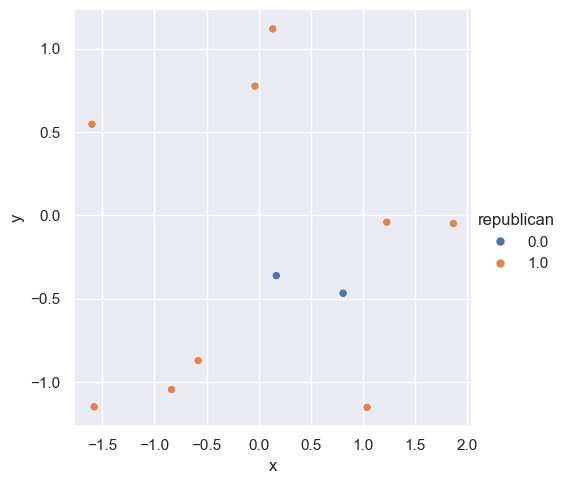

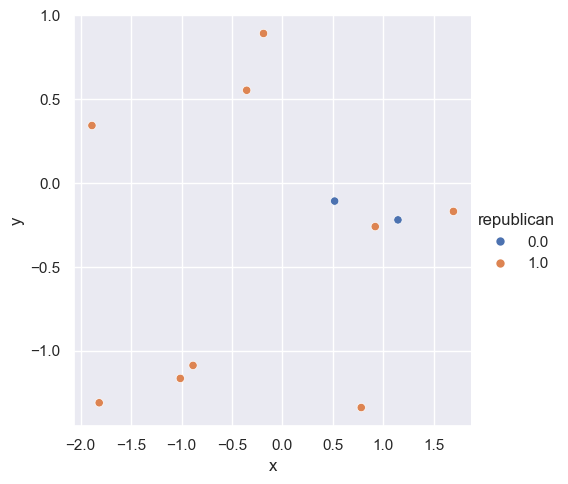

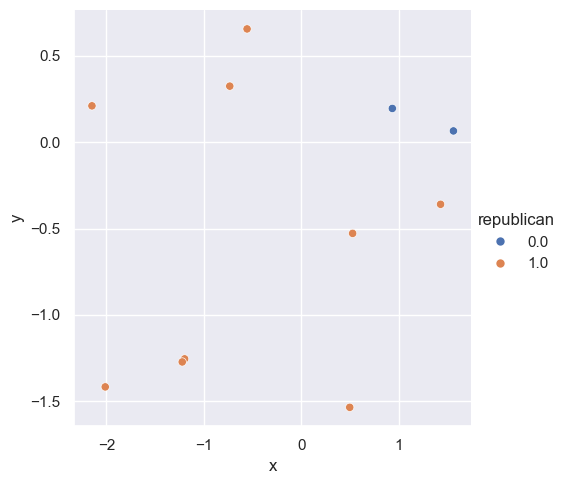

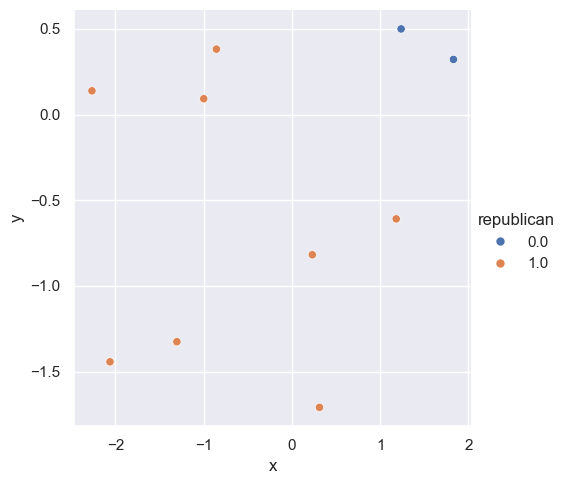

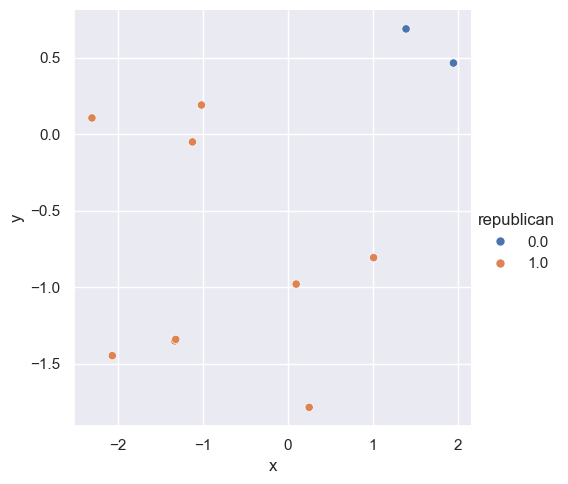

In [6]:
# Visualize the Judge Vectors
!pip install ggplot
import seaborn as sns
sns.set_theme()

judge_cites = dict(Y.groupby(J).mean())
df2 = pd.DataFrame(J,columns=['authorship']).drop_duplicates().sort_values('authorship')
df2['republican'] = df2['authorship'].apply(lambda x: judge_cites[x])

class GenericDataset(Dataset):

  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

model = EmbeddingNet(num_judges)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

dataset = GenericDataset(J, np.array(Y))
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

for i in range(5):
  if i > 0:
    for i, (X, label) in enumerate(loader):
      optimizer.zero_grad()
      outputs = model(X)
      loss = criterion(outputs, label.float().unsqueeze(1))
      loss.backward()
      optimizer.step()
  for name, param in model.named_parameters():
    if 'embedding' in name:
      judge_vectors = param.data
  df2['x'] = judge_vectors[:,0]
  df2['y'] = judge_vectors[:,1]    

  sns.relplot( data=df2, x="x", y="y", hue='republican', kind='scatter')


# Word Embeddings

In [7]:
from gensim.utils import tokenize
from collections import Counter
# keep the most frequent 200 words and convert documents to sequences of word indexes
tokenized_text = [list(tokenize(t, lowercase=True)) for t in df['opinion_text']]
whole_corpus = []
for t in tokenized_text:
  whole_corpus.extend(t)
common_words = set([t[0] for t in Counter(whole_corpus).most_common(200)])
word2id = {w : i + 1 for i, w in enumerate(common_words)}
filtered_sents = [[word2id[w] for w in t if w in common_words] for t in tokenized_text]

In [8]:
max_len = max([len(t) for t in filtered_sents])

In [9]:
# represent data as numrows x maxlen matrix
X = np.array([(max_len - len(s)) * [0] + s for s in filtered_sents])
X.shape

(768, 13924)

In [10]:
X[0]

array([  0,   0,   0, ..., 160, 157, 163], shape=(13924,))

In [11]:
X[0][max_len-len(filtered_sents[0]):]

array([ 57,  90, 197, ..., 160, 157, 163], shape=(1525,))

In [12]:
# Model setup

class EmbeddingNet(nn.Module):
  def __init__(self, num_words=200):
    super(EmbeddingNet, self).__init__()
    self.embedding = nn.Embedding(num_words + 1, 2)
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(2 * 13924, 4)
    self.fc2 = nn.Linear(4, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.embedding(x)
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.fc2(x)
    x = self.sigmoid(x)
    return x

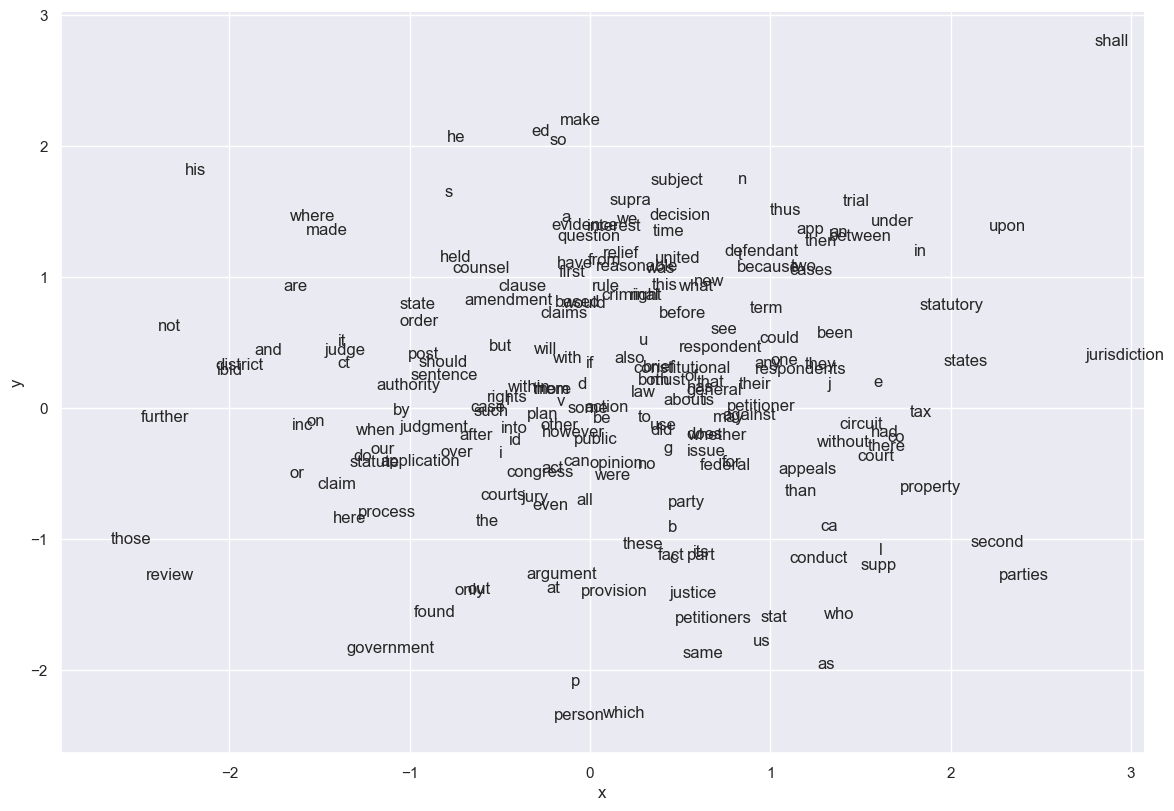

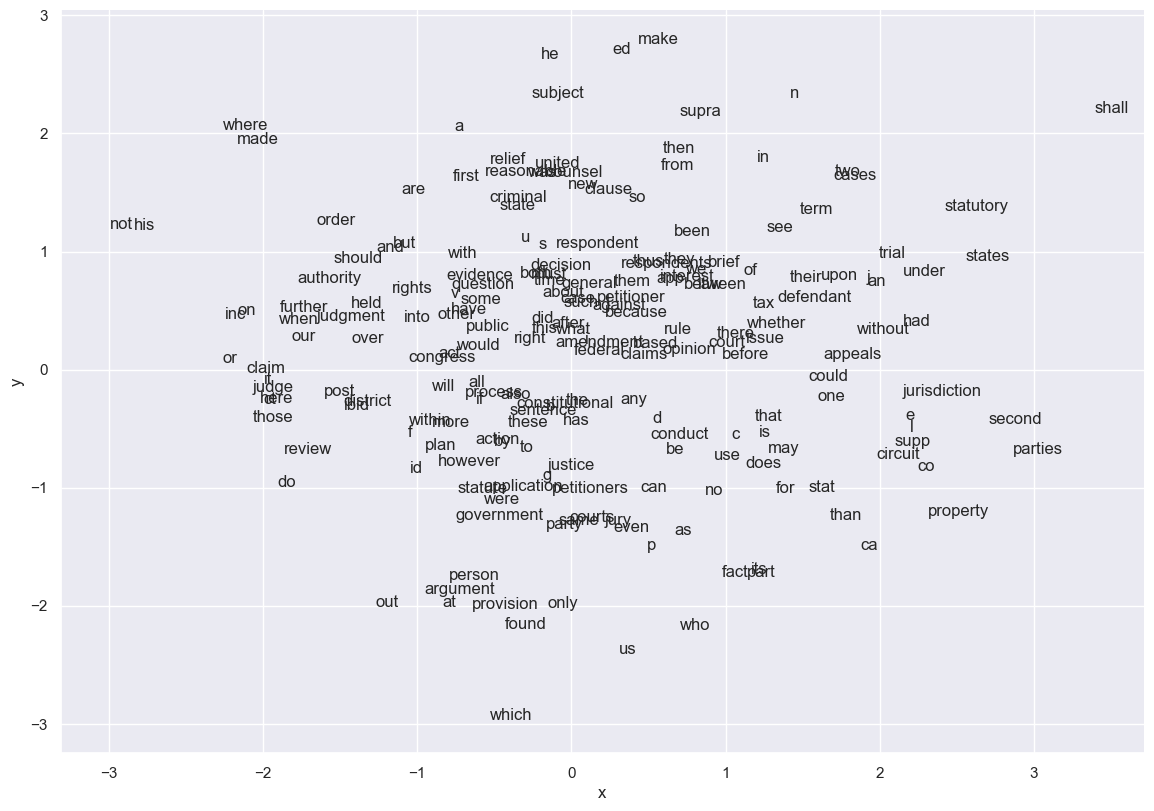

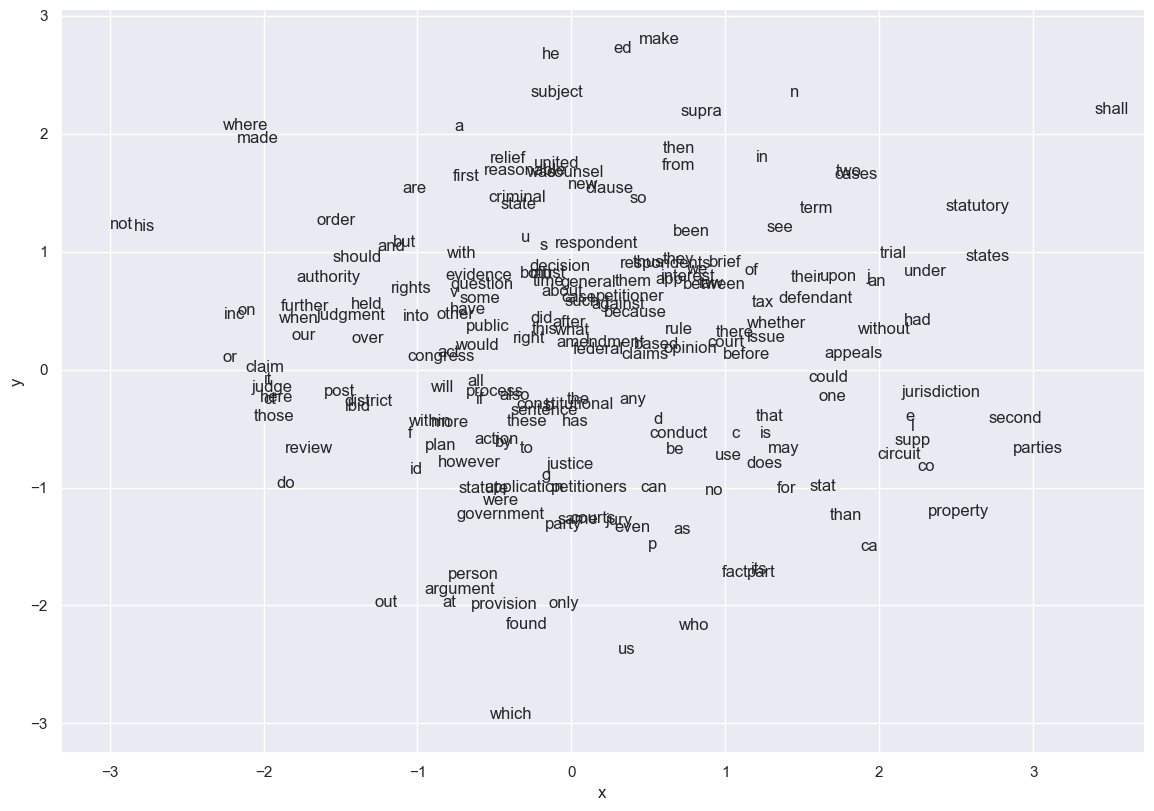

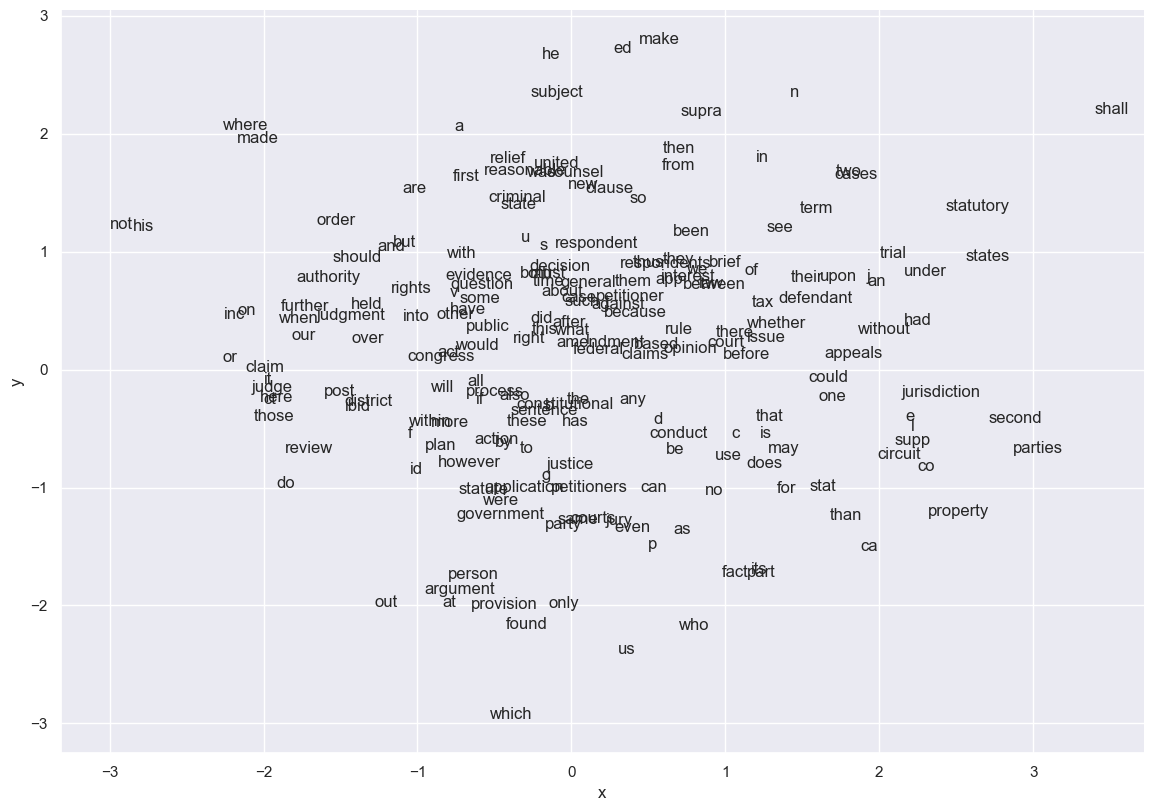

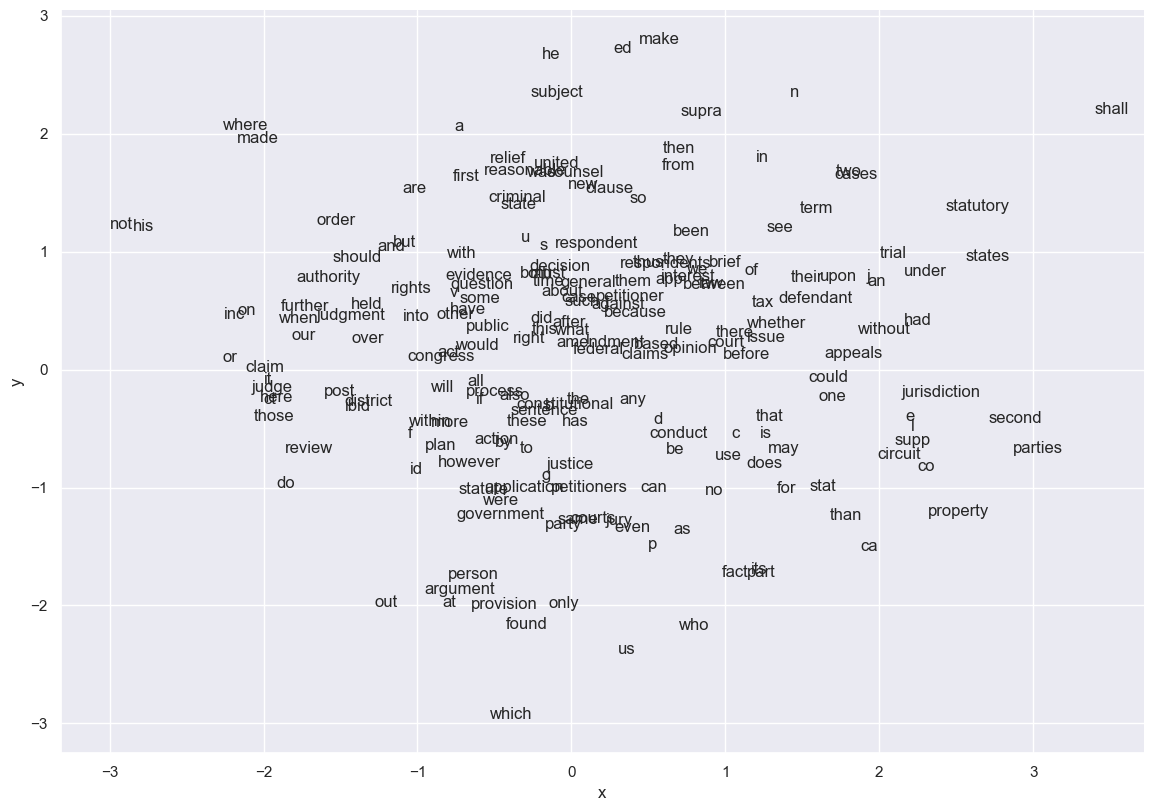

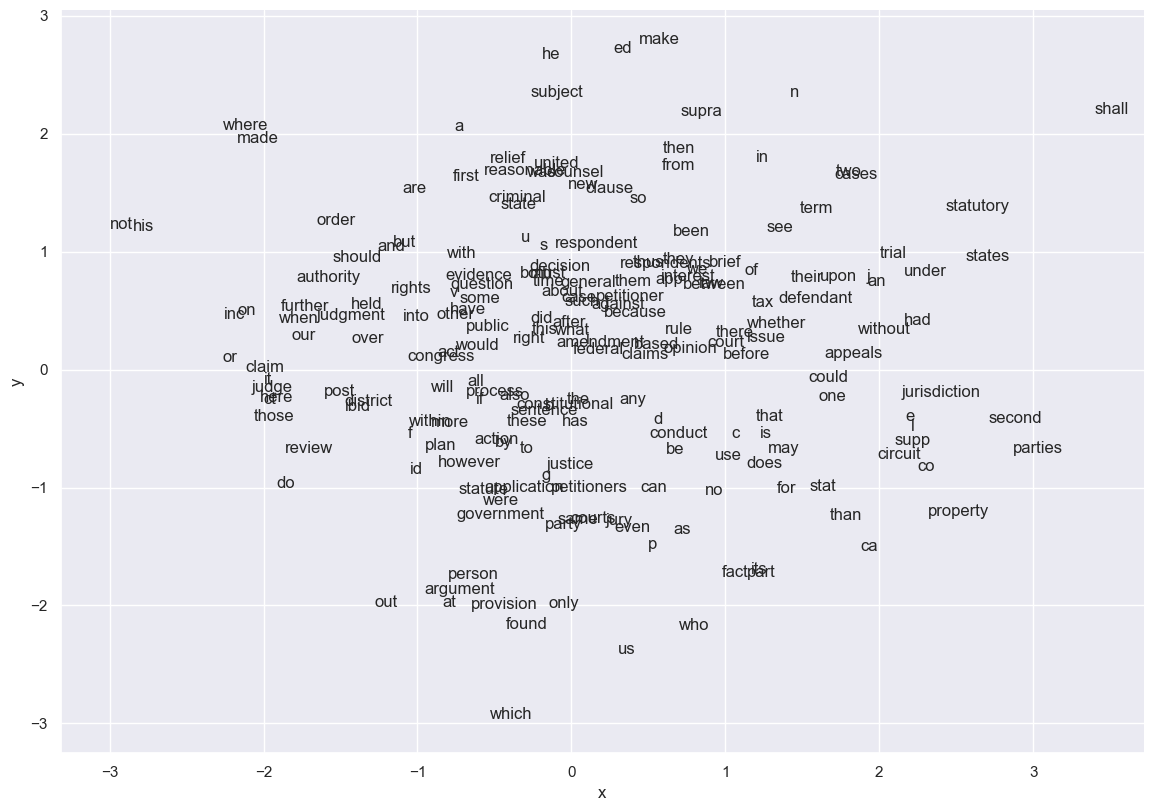

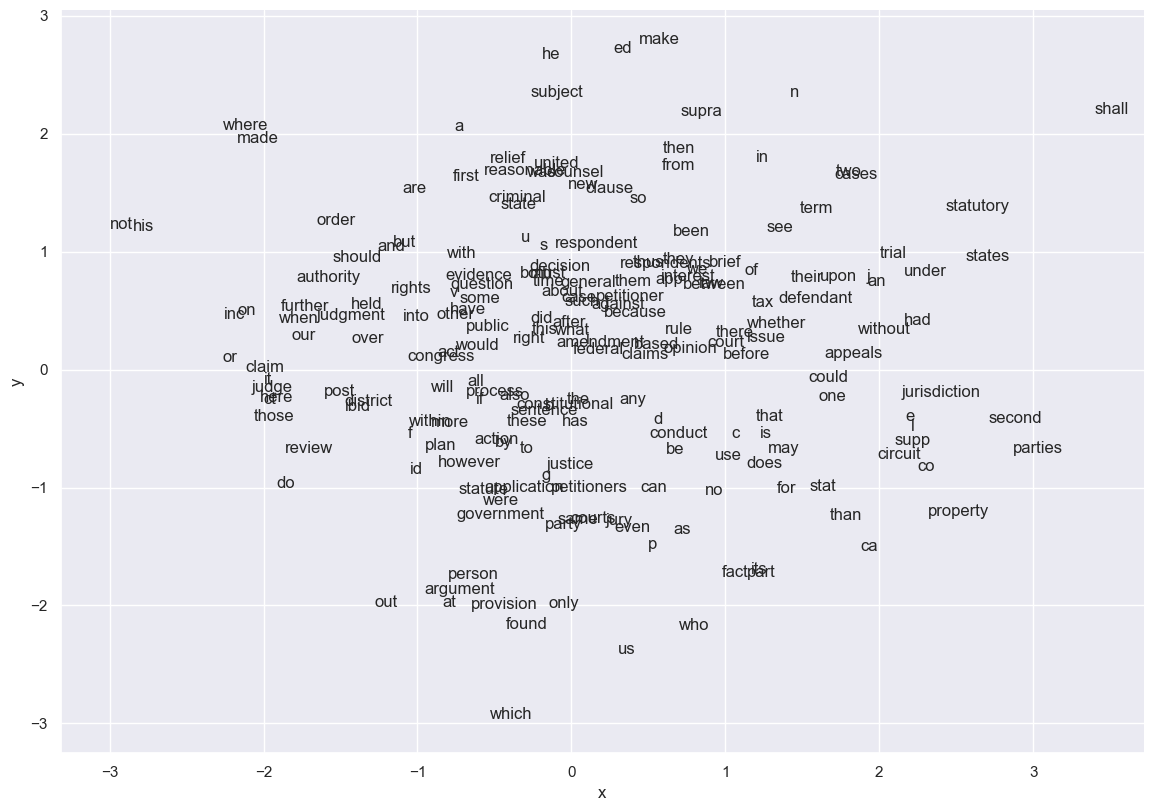

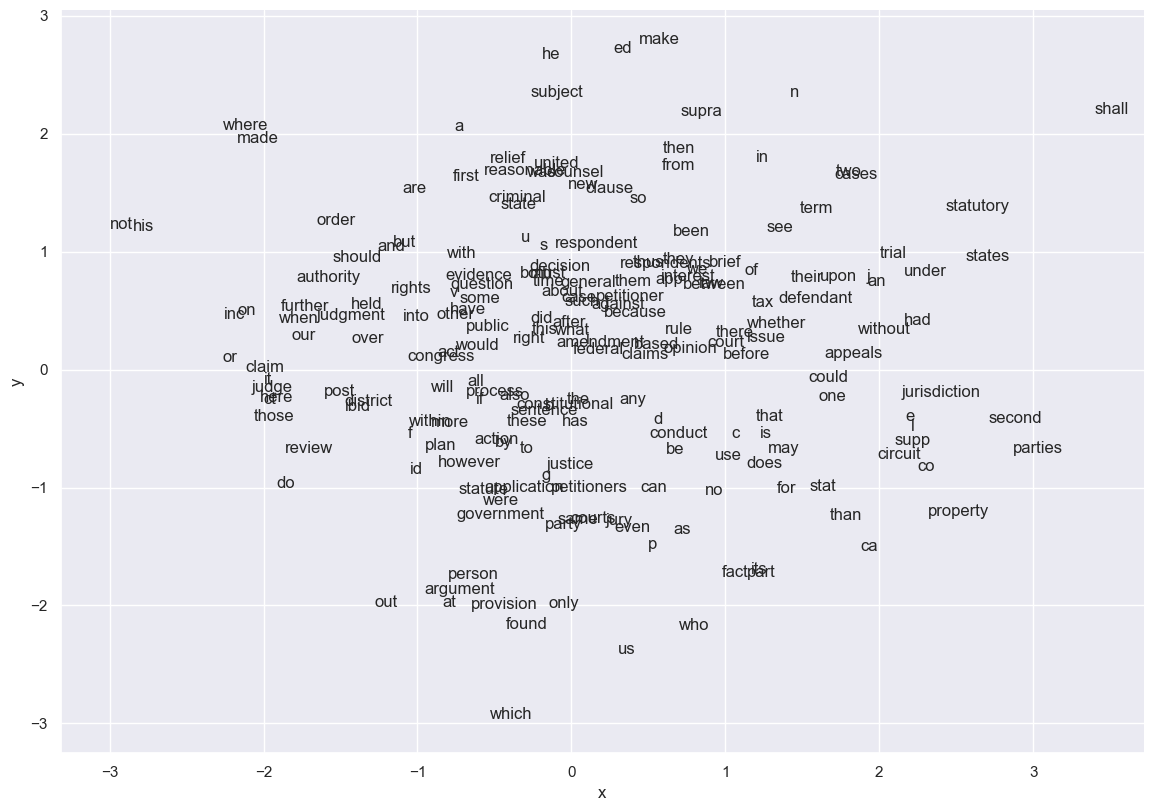

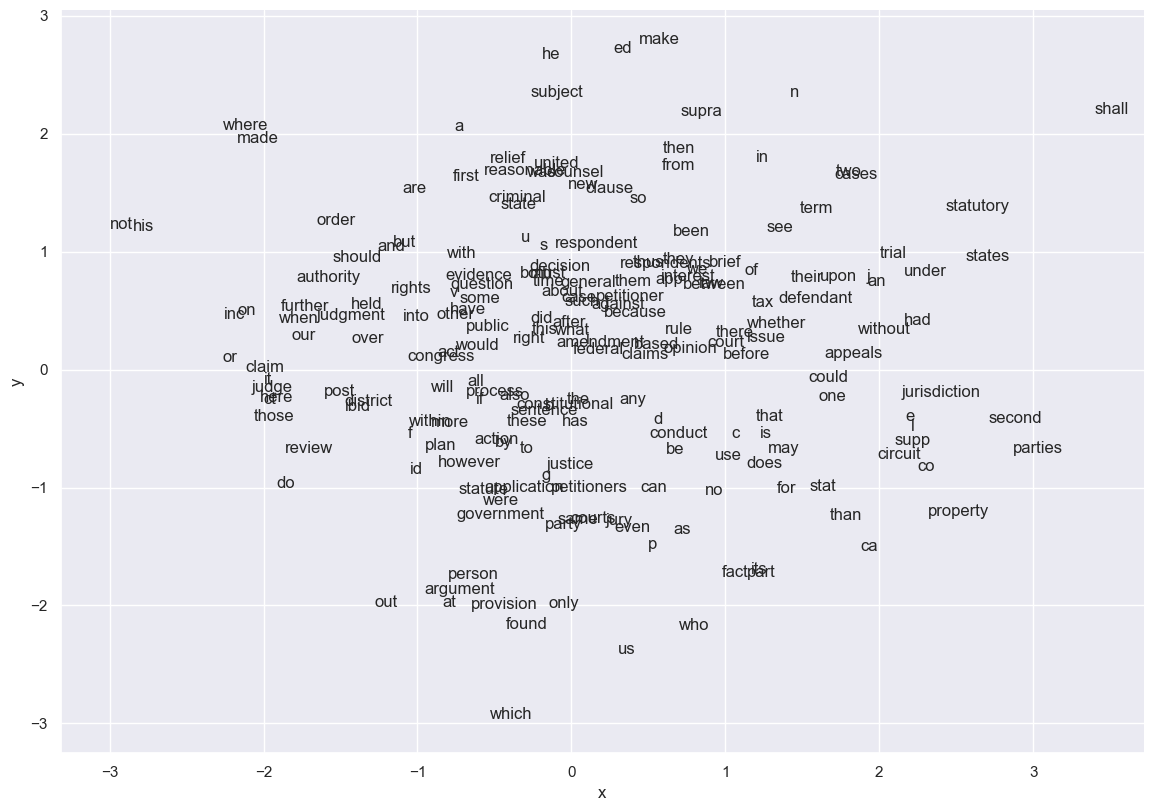

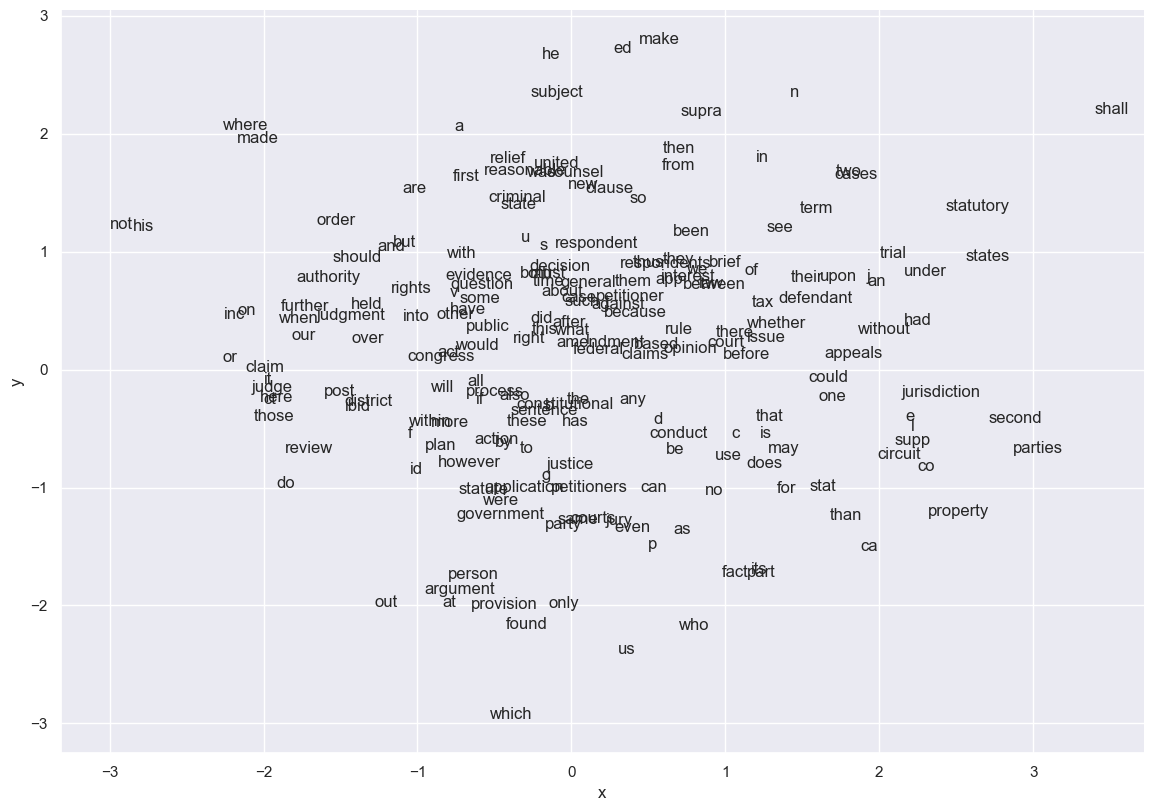

In [13]:
# show the vectors
from matplotlib import pyplot as plt

num_words = 200
df3 = pd.DataFrame(list(word2id.items()),
                  columns=['word', 'word_index']).sort_values('word_index')[:num_words]

model = EmbeddingNet(num_words)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

dataset = GenericDataset(X, np.array(Y))
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

for i in range(10):
  if i > 0:
    for data, label in loader:
      optimizer.zero_grad()
      outputs = model(data)
      loss = criterion(outputs, label.float().unsqueeze(1))
      loss.backward()
      optimizer.step()
  for name, param in model.named_parameters():
    if 'embedding' in name:
      word_vectors = param.data
  df3['x'] = word_vectors[1:,0]
  df3['y'] = word_vectors[1:,1]


  plot = sns.relplot( data=df3, x="x", y="y", s=0, height=8.27, aspect=11.7/8.27)

  for row in df3.itertuples():
      ax = plot.axes[0, 0]
      ax.text(row.x, row.y, row.word, horizontalalignment='left')
  plt.show()


In [14]:
# Word Similarity
from scipy.spatial.distance import cosine

vec_defendants = word_vectors[word2id['defendant']+1]
vec_sent = word_vectors[word2id['sentence']+1]
vec_against = word_vectors[word2id['against']+1]

print(1-cosine(vec_defendants, vec_sent))

-0.6924672


In [15]:
print(1-cosine(vec_defendants, vec_against))

-0.6511673


# Word2Vec in gensim

In [16]:
# word2vec requires sentences as input
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk import sent_tokenize
from string import punctuation
translator = str.maketrans('','',punctuation) 
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

def normalize_text(doc):
    "Input doc and return clean list of tokens"
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    lower = doc.lower() # all lower case
    nopunc = lower.translate(translator) # remove punctuation
    words = nopunc.split() # split into tokens
    nostop = [w for w in words if w not in stoplist] # remove stopwords
    no_numbers = [w if not w.isdigit() else '#' for w in nostop] # normalize numbers
    stemmed = [stemmer.stem(w) for w in no_numbers] # stem each word
    return stemmed

def get_sentences(doc):
    sent=[]
    for raw in sent_tokenize(doc):
        raw2 = normalize_text(raw)
        sent.append(raw2)
    return sent

sentences = []
for doc in df['opinion_text']:
    sentences += get_sentences(doc)
from random import shuffle
shuffle(sentences) # stream in sentences in random order

# train the model
from gensim.models import Word2Vec
w2v = Word2Vec(sentences,  # list of tokenized sentences
               workers = 8, # Number of threads to run in parallel
               vector_size=300,  # Word vector dimensionality     
               min_count =  25, # Minimum word count  
               window = 5, # Context window size      
               sample = 1e-3, # Downsample setting for frequent words
               )

# done training, so delete context vectors
w2v.init_sims(replace=True)

w2v.save('w2v-vectors.pkl')

w2v.wv['judg'] # vector for "judge"

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


array([ 0.01197342,  0.06357706,  0.0470336 , -0.0010519 ,  0.02703383,
       -0.0600732 , -0.12664618, -0.09000621, -0.00143886, -0.0144562 ,
        0.11114598,  0.00423961,  0.03937957, -0.13207428,  0.04064295,
       -0.08475798,  0.0434061 ,  0.007689  , -0.02995656,  0.11080056,
        0.07448415, -0.03884864,  0.03564299, -0.01996927, -0.06961914,
        0.04796439, -0.02605095, -0.04769049,  0.07026692,  0.05095512,
        0.0028561 ,  0.01135258, -0.03928762,  0.03639638,  0.03088943,
       -0.00027488,  0.02190799, -0.01757682, -0.00078884, -0.04483207,
        0.0837954 ,  0.02469341,  0.02710898,  0.02170883,  0.01050256,
        0.00253449,  0.00686184,  0.0056    , -0.08869916, -0.01633666,
        0.02394567, -0.08235889, -0.11890438, -0.12843877, -0.08922201,
       -0.0318756 , -0.01802742,  0.04524883,  0.01129806, -0.06712233,
       -0.08234965,  0.01791447,  0.07533816,  0.020343  ,  0.06246038,
       -0.05840935,  0.06124205,  0.08439163, -0.02815403, -0.10

In [17]:
w2v.wv.similarity('judg','juri') # similarity 

np.float32(0.5381567)

In [18]:
w2v.wv.most_similar('judg') # most similar words

[('bench', 0.5858579874038696),
 ('factfind', 0.5415802001953125),
 ('juri', 0.5381566882133484),
 ('court', 0.5297760367393494),
 ('panel', 0.5156570076942444),
 ('magistr', 0.5028176307678223),
 ('erron', 0.4986410439014435),
 ('unanim', 0.4890974760055542),
 ('special', 0.4857776463031769),
 ('speedi', 0.48065489530563354)]

In [20]:
# word2vec requires sentences as input
from nltk import sent_tokenize
from string import punctuation
translator = str.maketrans('','',punctuation) 
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

def normalize_text(doc):
    "Input doc and return clean list of tokens"
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    lower = doc.lower() # all lower case
    nopunc = lower#.translate(translator) # remove punctuation
    words = nopunc.split() # split into tokens
    nostop = [w for w in words ]#if w not in stoplist] # remove stopwords
    no_numbers = [w if not w.isdigit() else '#' for w in nostop] # normalize numbers
    stemmed = [stemmer.stem(w) for w in no_numbers] # stem each word
    return stemmed

def get_sentences(doc):
    sent=[]
    for raw in sent_tokenize(doc):
        raw2 = normalize_text(raw)
        sent.append(raw2)
    return sent

sentences = []
for doc in df['opinion_text']:
    sentences += get_sentences(doc)
from random import shuffle
shuffle(sentences) # stream in sentences in random order

# train the model
from gensim.models import Word2Vec
w2v = Word2Vec(sentences,  # list of tokenized sentences
               workers = 8, # Number of threads to run in parallel
               vector_size=300,  # Word vector dimensionality (renamed from 'size' in gensim 4.0)
               min_count =  25, # Minimum word count  
               window = 5, # Context window size      
               sample = 1e-3, # Downsample setting for frequent words
               )

w2v.save('w2v-vectors.pkl')

w2v.wv['judg'] # vector for "judge"

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


array([ 0.3005596 ,  0.09458282, -0.4055112 ,  1.0558541 ,  0.8554276 ,
        1.9058769 , -0.7297493 , -0.58526796, -0.3530246 ,  0.51824236,
        1.8563256 , -0.5558485 ,  0.29682246,  0.91633856, -0.45547545,
        0.12290197,  1.1372273 , -0.07021258, -1.4955773 ,  1.491792  ,
       -0.4691188 ,  0.5811944 ,  0.27311426, -0.26828867,  1.5747982 ,
        1.793791  ,  0.6111835 , -0.44683266,  1.2727151 , -0.57088166,
        0.18354313,  0.5485518 ,  0.6115885 ,  0.43808693, -1.0485502 ,
        1.4553833 , -0.5313847 ,  0.74600226,  0.00452551, -1.5920053 ,
       -1.2029788 ,  0.37674776,  0.92223096,  0.80466896, -0.42539522,
       -0.8810144 ,  0.4823592 , -0.6767139 , -1.3909987 ,  0.5156178 ,
       -1.057222  , -0.1187975 ,  1.9078436 ,  1.0834293 ,  0.9850764 ,
       -0.92559046, -0.9671885 , -0.32400805, -0.48728663, -0.6586079 ,
        1.112475  ,  0.20317483, -1.165844  ,  0.2827858 ,  0.12539428,
       -0.09889407, -0.10552708,  0.20851602,  0.82059973,  0.50

In [22]:
# word2vec requires sentences as input
from nltk import sent_tokenize
from string import punctuation
translator = str.maketrans('','',punctuation) 
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

def normalize_text(doc):
    "Input doc and return clean list of tokens"
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    lower = doc.lower() # all lower case
    nopunc = lower#.translate(translator) # remove punctuation
    words = nopunc.split() # split into tokens
    nostop = [w for w in words ]#if w not in stoplist] # remove stopwords
    no_numbers = [w if not w.isdigit() else '#' for w in nostop] # normalize numbers
    stemmed = [stemmer.stem(w) for w in no_numbers] # stem each word
    return stemmed

def get_sentences(doc):
    sent=[]
    for raw in sent_tokenize(doc):
        raw2 = normalize_text(raw)
        sent.append(raw2)
    return sent

sentences = []
for doc in df['opinion_text']:
    sentences += get_sentences(doc)
from random import shuffle
shuffle(sentences) # stream in sentences in random order

# train the model
from gensim.models import Word2Vec
w2v = Word2Vec(sentences,  # list of tokenized sentences
               workers = 8, # Number of threads to run in parallel
               vector_size=300,  # Word vector dimensionality     
               min_count =  25, # Minimum word count  
               window = 5, # Context window size      
               sample = 1e-3, # Downsample setting for frequent words
               )

# done training, so delete context vectors
w2v.init_sims(replace=True)

w2v.save('w2v-vectors.pkl')

w2v.wv['judg'] # vector for "judge"

KeyboardInterrupt: 

In [23]:
w2v.wv.similarity('judg','juri') # similarity 

np.float32(0.62908274)

In [24]:
# analogies: judge is to man as __ is to woman
w2v.wv.most_similar(positive=['judg','man'],
                 negative=['woman'])

[('judge,', 0.7022194862365723),
 ('jury,', 0.5477532744407654),
 ('juri', 0.5133346915245056),
 ('prosecutor', 0.5021111965179443),
 ('juror', 0.49793413281440735),
 ('wit', 0.48075512051582336),
 ('court', 0.4743570387363434),
 ('magistr', 0.46433278918266296),
 ('you', 0.46258386969566345),
 ('judges,', 0.4620944857597351)]

In [38]:
# Word2Vec: K-Means Clusters
from sklearn.cluster import KMeans
kmw = KMeans(n_clusters=50)
kmw.fit(w2v.wv.vectors)
judge_clust = kmw.labels_[w2v.wv.key_to_index['judg']]
for i, cluster in enumerate(kmw.labels_):
    if cluster == judge_clust and i<=100:
        print(w2v.wv.index_to_key[i])

his
petition
he
respond
they
defend


# Pre-trained vectors

In [39]:
import spacy
en = spacy.load('en_core_web_sm')
apple = en('apple') 
apple.vector # vector for 'apple'

array([-1.1838133 , -0.8882773 , -0.29408097, -0.59344876,  0.16648422,
       -0.53846365,  0.96148324,  0.216802  , -0.4790685 , -0.27562743,
        0.29058665, -1.049209  , -0.37911066,  0.5312755 ,  0.47206905,
        1.4448833 , -0.8657664 , -0.47400755,  0.98587227, -0.19452083,
       -0.43302864,  0.7619376 , -0.41693196, -0.37797722,  1.3568695 ,
        0.03237271,  1.0276382 ,  0.40241203, -0.73181367,  1.3942685 ,
       -0.38214552,  0.16122654,  0.01030424, -0.23572314, -0.20571312,
       -0.7032237 , -0.22249547,  0.65576416, -0.00793771, -0.18970338,
       -0.4086491 , -0.01591997, -0.20140037,  0.35885602,  0.28791487,
       -0.42096803, -0.22308233, -0.74895513,  0.12641451, -0.5474181 ,
        0.05564304, -0.3097041 , -0.11853766, -0.20757279,  1.0038178 ,
        0.03209786,  1.2394714 ,  0.12958106, -0.22994503,  0.12284425,
       -0.7941426 , -0.30465376, -0.05707061, -0.6131594 , -0.0583915 ,
        0.56547695,  0.37080353,  0.13290007, -0.22842097, -0.30

In [40]:
apple.similarity(apple)

1.0

In [41]:
orange = en('orange')
apple.similarity(orange)

0.4297249913215637

In [43]:
import spacy
!python -m spacy download de_core_news_sm
de = spacy.load('de_core_news_sm')
apfel = de('apfel')
orange = de('orange')
apfel.similarity(orange)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 34.9 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


0.023909490555524826

In [48]:
# Initializing an embedding layer with pre-trained vectors
embed_dims = len(apple.vector)
embedding_matrix = np.zeros([num_words, embed_dims])
for word, i in word2id.items():
    if i > num_words:
        break
    embedding_vector = en(word).vector
    embedding_matrix[i-1] = embedding_vector    

In [49]:
class EmbeddingNet(nn.Module):
  def __init__(self, num_words=200):
    super(EmbeddingNet, self).__init__()
    self.embedding = nn.Embedding(num_words + 1, 96)
    with torch.no_grad():
      self.embedding.weight[1:, :] = torch.nn.Parameter(torch.from_numpy(embedding_vector))
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(96 * 13924, 64)
    self.relu1 = nn.ReLU()
    self.fc2 = nn.Linear(64, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.embedding(x)
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu1(x)
    x = self.fc2(x)
    x = self.sigmoid(x)
    return x


[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 201 samples in 0.002s...
[t-SNE] Computed neighbors for 201 samples in 0.053s...
[t-SNE] Computed conditional probabilities for sample 201 / 201
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 17.348101
[t-SNE] KL divergence after 300 iterations: -1.180992


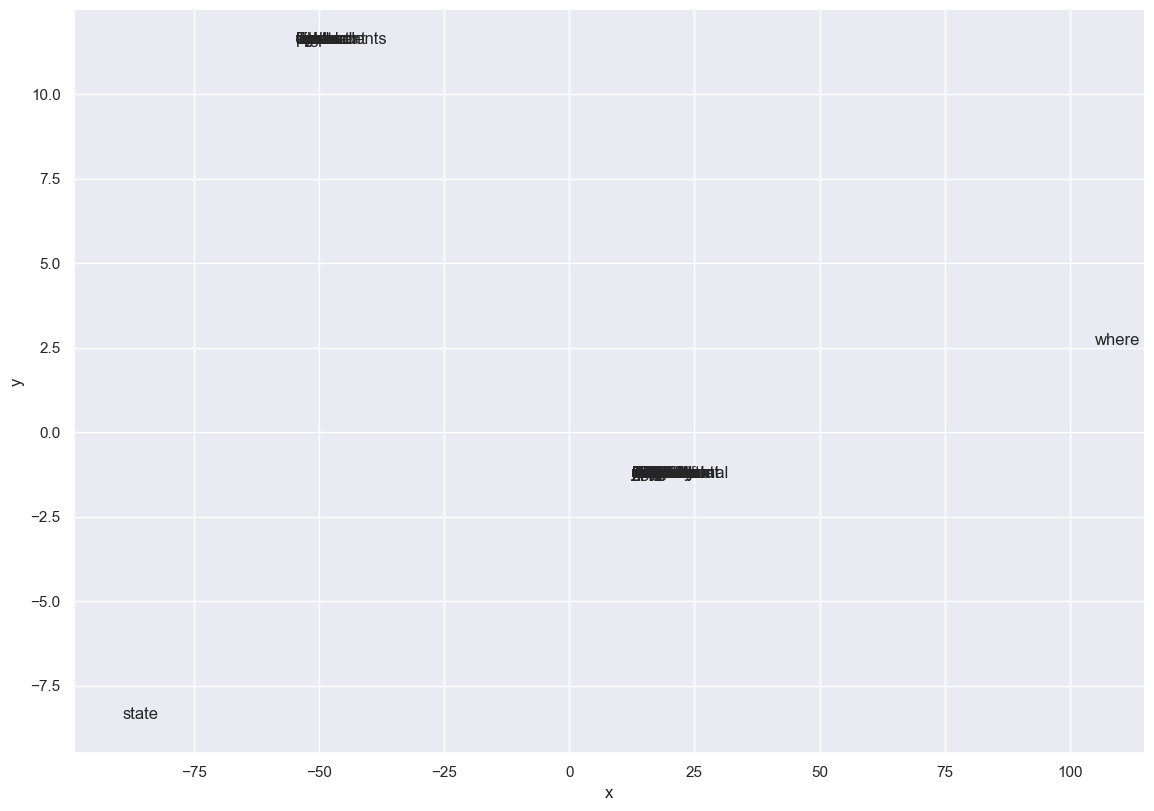

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 201 samples in 0.000s...
[t-SNE] Computed neighbors for 201 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 201 / 201
[t-SNE] Mean sigma: 0.014738
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.983490
[t-SNE] KL divergence after 300 iterations: 1.809655


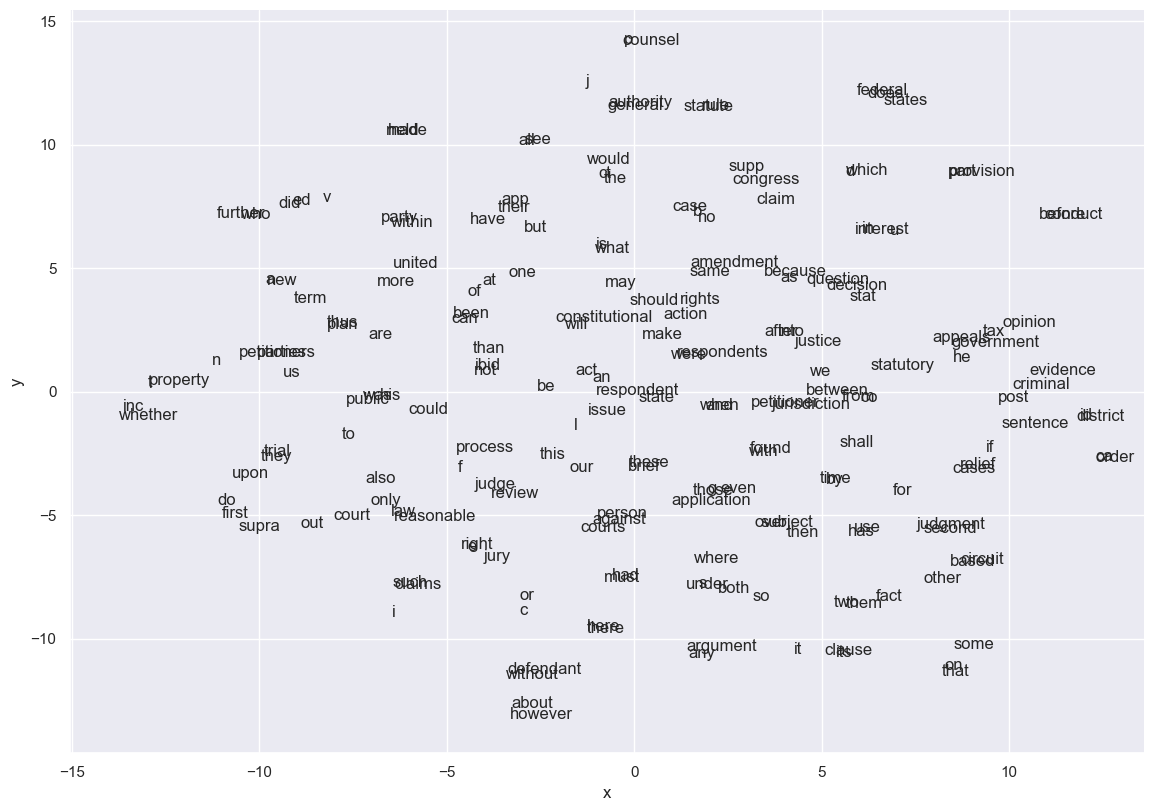

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 201 samples in 0.001s...
[t-SNE] Computed neighbors for 201 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 201 / 201
[t-SNE] Mean sigma: 0.014858
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.158081
[t-SNE] KL divergence after 300 iterations: 1.817027


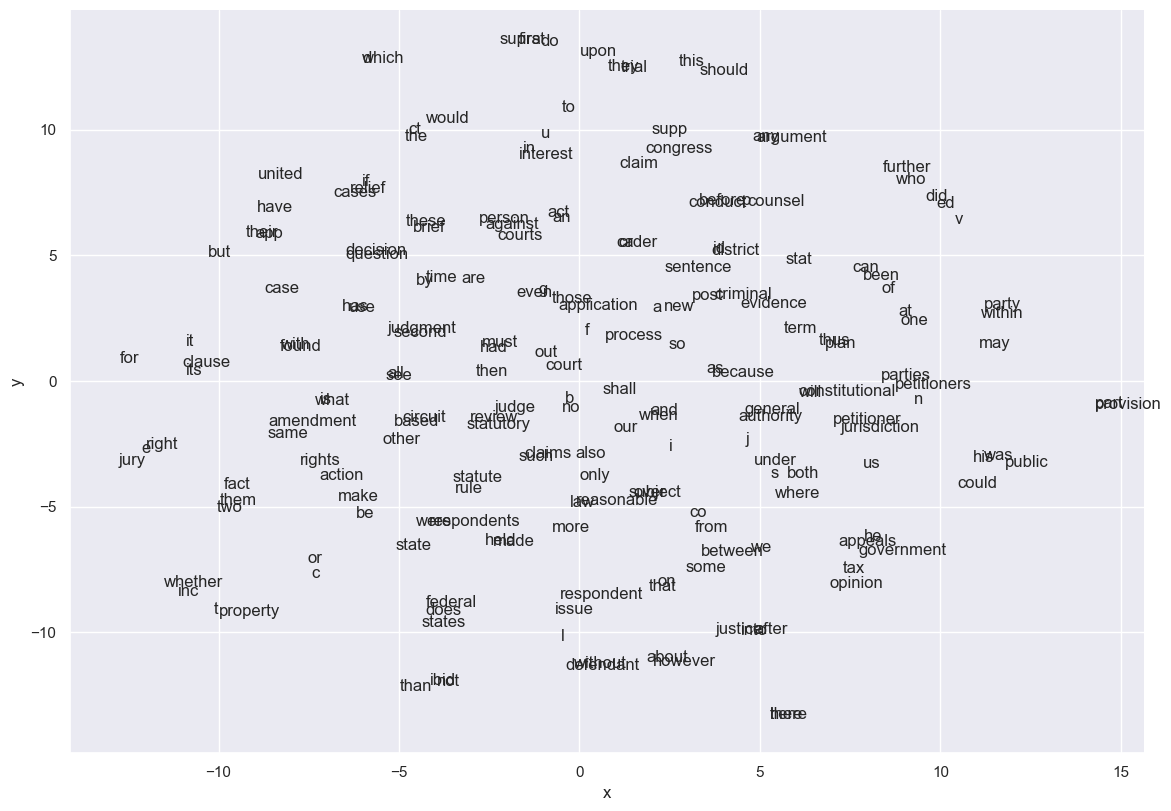

In [50]:
# show the vectors
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, verbose=1, perplexity=10, max_iter=300)

df3 = pd.DataFrame(list(word2id.items()),
                  columns=['word', 'word_index']).sort_values('word_index')[:num_words]
model = EmbeddingNet()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

dataset = GenericDataset(X, np.array(Y))
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)
for i in range(3):
  if i > 0:
    for data, label in loader:
      optimizer.zero_grad()
      outputs = model(data)
      loss = criterion(outputs, label.float().unsqueeze(1))
      loss.backward()
      optimizer.step()
  for name, param in model.named_parameters():
    if 'embedding' in name:
      word_vectors = param.data
  wv_tsne = tsne.fit_transform(word_vectors)
  df3['x'] = wv_tsne[1:,0]
  df3['y'] = wv_tsne[1:,1]
  plot = sns.relplot( data=df3, x="x", y="y", s=0, height=8.27, aspect=11.7/8.27)

  for row in df3.itertuples():
      ax = plot.axes[0, 0]
      ax.text(row.x, row.y, row.word, horizontalalignment='left')
  plt.show()

# Fast Text
See more at https://github.com/facebookresearch/fastText#example-use-cases

In [52]:
!pip install fasttext

In [53]:
import fasttext

with open('data.txt', 'w') as f:
  for i, t in enumerate(df['opinion_text']):
    f.write(t + '\n')
    if i > 5:
      break
# train a Skipgram model :
model = fasttext.train_unsupervised('data.txt', model='skipgram')

Read 0M words
Number of words:  933
Number of labels: 0
Progress: 100.0% words/sec/thread:   77689 lr:  0.000000 avg.loss:  2.808026 ETA:   0h 0m 0s


In [54]:
model.words[:100]

['the',
 'of',
 'to',
 'a',
 '</s>',
 'that',
 'and',
 'in',
 'for',
 'at',
 'is',
 'not',
 'or',
 'by',
 'be',
 '§',
 'as',
 'on',
 'The',
 'with',
 'an',
 'v.',
 'L.',
 'U.S.',
 'Ed.',
 'S.',
 'Ct.',
 '2d',
 'this',
 '.',
 'was',
 'from',
 'federal',
 'Court',
 'are',
 'we',
 'See',
 'had',
 'have',
 'it',
 'would',
 'court',
 'which',
 'his',
 'class',
 'whether',
 'were',
 'he',
 'state',
 'any',
 'under',
 'they',
 'liability',
 'case',
 'trial',
 'In',
 'Id.,',
 '--',
 'such',
 "Lee's",
 'F.3d',
 'We',
 'may',
 'devices',
 'Lee',
 'when',
 'also',
 'its',
 'because',
 'their',
 'no',
 'United',
 'States',
 'law',
 'Rule',
 'has',
 'It',
 'District',
 'App.',
 'maritime',
 'Federal',
 'other',
 'see',
 'been',
 'all',
 'U.S.C.',
 'motion',
 'could',
 'continuance',
 'Brief',
 'decision',
 'did',
 'if',
 'only',
 'review',
 'ICC',
 'should',
 'members',
 'witnesses',
 'warning']

In [55]:
model['state']

array([ 0.01540929,  0.27062285,  0.06172006,  0.0657718 , -0.05940125,
        0.22777002, -0.21320836, -0.28611428,  0.04338415,  0.1568035 ,
        0.03439536, -0.22316507, -0.05374176,  0.14523432,  0.15679985,
       -0.0279648 , -0.06456415, -0.05854551,  0.08914811, -0.16543412,
       -0.19486645, -0.05271499, -0.14230007, -0.05303545, -0.11185312,
       -0.09740639, -0.12565938,  0.12403387, -0.41346407,  0.08883277,
        0.07046054, -0.16894633, -0.05876911, -0.10893507, -0.0330604 ,
       -0.09758051, -0.18674135, -0.01414903,  0.05154429,  0.17375092,
        0.2857358 ,  0.26102078,  0.00167414,  0.07790827,  0.17235044,
       -0.05120746, -0.06221391,  0.05592585, -0.12347913, -0.23736699,
        0.1020917 ,  0.00198456,  0.11396253, -0.08278147,  0.10850365,
       -0.14785741,  0.09236641,  0.07121012, -0.05402794, -0.20612486,
        0.10838729, -0.06594384,  0.02835472, -0.00483949,  0.10408547,
        0.00948641, -0.08243598, -0.12200311, -0.0752371 ,  0.06

# Embedding Lookup

Keras provides functionality to feed just words (actually indices of words) as model input. The model then performs an embedding lookup (we go from sparse one-hot to dense) which then becomes the input for further computation in the model. For a more detailed tutorial, have a look [here](https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/). 

First, we have to pre-process the data once again

In [61]:
#df['opinion_text']

import re

def text_to_word_sequence(text, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True):
    if lower:
        text = text.lower()
    text = re.sub('[' + re.escape(filters) + ']', ' ', text)
    return [w for w in text.split() if w]

# tokenize the text
tokenized = [text_to_word_sequence(opinion) for opinion in df["opinion_text"]]
print(tokenized[0][:50])

['chief', 'justice', 'roberts', 'delivered', 'the', 'opinion', 'of', 'the', 'court', 'bad', 'things', 'happen', 'if', 'you', 'fail', 'to', 'pay', 'federal', 'income', 'taxes', 'when', 'due', 'one', 'of', 'them', 'is', 'that', 'interest', 'accrues', 'on', 'the', 'unpaid', 'amount', 'sometimes', 'it', 'takes', 'a', 'while', 'for', 'the', 'internal', 'revenue', 'service', 'irs', 'to', 'determine', 'that', 'taxes', 'should', 'have']


In [63]:
from collections import Counter
counter = Counter()
for i in tokenized:
        counter.update(i)
print (counter.most_common(10))
num_words = len(counter)
print (num_words) ## 58'787
print (max(len(i) for i in tokenized)) # 26'097, this is one of the challenges of working with legal text

[('the', 268094), ('of', 135373), ('to', 107507), ('a', 87432), ('that', 75017), ('in', 72525), ('and', 65488), ('s', 50776), ('at', 40610), ('for', 37387)]
58737
26097


In [64]:
# create one_hot representation for each word
!pip install Keras-Preprocessing
from keras_preprocessing.text import one_hot
from keras_preprocessing.sequence import pad_sequences
length_vocab = 10000
X_one_hot = [one_hot(opinion, n=length_vocab) for opinion in df["opinion_text"]]
print (X_one_hot[0][:50])

[7187, 209, 7082, 8142, 238, 7714, 1472, 238, 1548, 6621, 3147, 7143, 7362, 9017, 9150, 3966, 321, 9191, 1920, 9030, 8474, 9966, 527, 1472, 5843, 3079, 4343, 2483, 7306, 977, 238, 884, 9009, 8062, 1062, 6069, 2189, 328, 6712, 238, 1853, 3425, 4792, 2984, 3966, 3780, 4343, 9030, 8218, 7292]


In [66]:
# next, we pad (or truncate) such that all the inputs have same length
np.unicode_ = np.str_  # fix for NumPy 2.0 removing np.unicode_

max_seq_length = 2000
X_one_hot_padded = pad_sequences(X_one_hot, padding='post', maxlen=max_seq_length, truncating='post')
X_one_hot_padded.shape # (768, 2000)

(768, 2000)

In [69]:
# word2vec requires sentences as input
from nltk import sent_tokenize
from string import punctuation
translator = str.maketrans('','',punctuation) 
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

def normalize_text(doc):
    "Input doc and return clean list of tokens"
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    lower = doc.lower() # all lower case
    nopunc = lower#.translate(translator) # remove punctuation
    words = nopunc.split() # split into tokens
    nostop = [w for w in words ]#if w not in stoplist] # remove stopwords
    no_numbers = [w if not w.isdigit() else '#' for w in nostop] # normalize numbers
    stemmed = [stemmer.stem(w) for w in no_numbers] # stem each word
    return stemmed

def get_sentences(doc):
    sent=[]
    for raw in sent_tokenize(doc):
        raw2 = normalize_text(raw)
        sent.append(raw2)
    return sent

sentences = []
for doc in df['opinion_text']:
    sentences += get_sentences(doc)
from random import shuffle
shuffle(sentences) # stream in sentences in random order

# train the model
from gensim.models import Word2Vec
w2v = Word2Vec(sentences,  # list of tokenized sentences
               workers = 8, # Number of threads to run in parallel
               vector_size=300,  # Word vector dimensionality     
               min_count =  25, # Minimum word count  
               window = 5, # Context window size      
               sample = 1e-3, # Downsample setting for frequent words
               )

# done training, so delete context vectors
w2v.init_sims(replace=True)

w2v.save('w2v-vectors.pkl')

w2v.wv['judg'] # vector for "judge"

array([-3.97579409e-02, -3.36572118e-02, -4.21460643e-02,  5.96015230e-02,
       -1.64688530e-03,  1.34787217e-01, -7.78855681e-02, -7.99765736e-02,
        9.84991249e-03,  7.48689547e-02,  6.27543554e-02,  9.91773326e-03,
       -2.83909254e-02,  9.03136134e-02, -3.17400061e-02,  3.38037536e-02,
        7.97109213e-03, -2.06523258e-02, -8.07379000e-03,  8.39682370e-02,
        2.82410961e-02,  1.26489684e-01, -1.31845558e-02, -1.72410067e-02,
        3.71057354e-02,  1.03203997e-01,  6.76067322e-02,  3.38385627e-02,
        1.04191281e-01,  3.72808725e-02,  4.45515662e-02,  1.60053298e-01,
        4.65693697e-02,  4.71159555e-02, -5.75195216e-02,  1.28332406e-01,
        4.46340069e-02,  4.52702753e-02, -5.63941710e-02, -4.43718694e-02,
       -8.41086581e-02,  1.49080101e-02,  7.49266520e-02,  2.68219505e-02,
       -6.66775554e-03,  1.75791699e-03,  8.16011727e-02,  7.43873185e-03,
       -3.83451134e-02,  5.02293855e-02,  9.38288867e-04,  4.54341210e-02,
        8.61012191e-02,  

**Embedding lookup**

In [70]:
from keras.layers import Embedding
from keras.models import Sequential

model = Sequential() # create a sequential model
model.add(Embedding(length_vocab, 64, input_length=max_seq_length, name="embedding_layer"))
model.summary() #640'000 params because 64 dim for 10'000 words

# that's it


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# GloVe

In [5]:
!pip install mittens

from collections import Counter
import numpy as np
from tqdm import tqdm
from mittens import GloVe as GloVeModel
from nltk import sent_tokenize
from string import punctuation
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

translator = str.maketrans('','',punctuation)
stoplist = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

def normalize_text(doc):
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    nopunc = doc.lower().translate(translator)
    words = nopunc.split()
    nostop = [w for w in words if w not in stoplist]
    return [stemmer.stem(w) for w in nostop if not w.isdigit()]

sentences = []
for doc in tqdm(df['opinion_text'], desc='Tokenizing'):
    sentences += [normalize_text(s) for s in sent_tokenize(doc)]

# Build vocabulary (words appearing >= 25 times)
word_counts = Counter(w for s in sentences for w in s)
vocab = [w for w, c in word_counts.most_common() if c >= 25]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocabulary size: {len(vocab)}')

# Build windowed co-occurrence matrix (window=10, numpy-vectorized)
n = len(vocab)
cooc = np.zeros((n, n), dtype=np.float32)
for sent in tqdm(sentences, desc='Building co-occurrence'):
    idxs = np.array([word2idx[w] for w in sent if w in word2idx])
    for i in range(len(idxs)):
        window_idxs = np.concatenate([idxs[max(0,i-10):i], idxs[i+1:min(len(idxs),i+11)]])
        cooc[idxs[i], window_idxs] += 1.0

print(f'Co-occurrence matrix: {cooc.shape}')

Tokenizing: 100%|██████████| 768/768 [00:15<00:00, 48.11it/s]


Vocabulary size: 5419


Building co-occurrence: 100%|██████████| 235507/235507 [00:06<00:00, 38328.68it/s]

Co-occurrence matrix: (5419, 5419)


In [6]:
# Train GloVe (100 dimensions, 100 iterations)
glove_model = GloVeModel(n=100, max_iter=100)
embeddings = glove_model.fit(cooc)

# Build word -> vector lookup
glove_wv = {word: embeddings[i] for word, i in word2idx.items()}
print('Training complete')

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


I0000 00:00:1779361350.405975 21471096 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
Iteration 100: loss: 46483.1718755

Training complete


In [7]:
from scipy.spatial.distance import cosine

def most_similar(word, topn=10):
    if word not in glove_wv:
        return []
    vec = glove_wv[word]
    sims = [(w, 1 - cosine(vec, glove_wv[w])) for w in glove_wv if w != word]
    return sorted(sims, key=lambda x: -x[1])[:topn]

most_similar('judg')

[('trial', np.float32(0.87500924)),
 ('find', np.float32(0.86293817)),
 ('juri', np.float32(0.85851055)),
 ('found', np.float32(0.8403485)),
 ('consid', np.float32(0.84007293)),
 ('follow', np.float32(0.83098173)),
 ('determin', np.float32(0.830741)),
 ('court', np.float32(0.8274656)),
 ('case', np.float32(0.82284814)),
 ('relev', np.float32(0.82022655))]

In [9]:
most_similar('judg')

[('trial', np.float32(0.87500924)),
 ('find', np.float32(0.86293817)),
 ('juri', np.float32(0.85851055)),
 ('found', np.float32(0.8403485)),
 ('consid', np.float32(0.84007293)),
 ('follow', np.float32(0.83098173)),
 ('determin', np.float32(0.830741)),
 ('court', np.float32(0.8274656)),
 ('case', np.float32(0.82284814)),
 ('relev', np.float32(0.82022655))]


# Word Mover Distance

Word Mover’s Distance (WMD) is a promising tool (based on word2vec) in machine learning that allows us to submit a query and return the most relevant documents. The intuition behind the method is that we find the minimum “traveling distance” between documents, in other words the most efficient way to “move” the distribution of document 1 to the distribution of document 2.

In [10]:
sentence_obama = 'Obama speaks to the media in Illinois'
sentence_president = 'The president greets the press in Chicago'

In [11]:
# Import and download stopwords from NLTK.
from nltk.corpus import stopwords
from nltk import download
download('stopwords')  # Download stopwords list.
stop_words = stopwords.words('english')

def preprocess(sentence):
    return [w for w in sentence.lower().split() if w not in stop_words]

sentence_obama = preprocess(sentence_obama)
sentence_president = preprocess(sentence_president)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
import gensim.downloader as api
model = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [14]:
!pip install POT
distance = model.wmdistance(sentence_obama, sentence_president)
print('distance = %.4f' % distance)

distance = 1.0175


In [15]:
sentence_orange = preprocess('Oranges are my favorite fruit')
distance = model.wmdistance(sentence_obama, sentence_orange)
print('distance = %.4f' % distance)

distance = 1.3664
